In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

#Gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

directorio_notebook = Path(os.getcwd())

if directorio_notebook.name == "notebooks":
    raiz_proyecto = directorio_notebook.parent
else:
    raiz_proyecto = directorio_notebook

ruta_csv = raiz_proyecto / "data" / "raw" / "autos_crudos.csv"

print(f"Buscando archivo en ruta relativa limpia: {ruta_csv.relative_to(raiz_proyecto)}")

df = pd.read_csv(ruta_csv)

df.head()

: 

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   titulo       1000 non-null   str  
 1   precio       1000 non-null   str  
 2   ano          1000 non-null   str  
 3   kilometraje  1000 non-null   str  
dtypes: str(4)
memory usage: 31.4 KB


In [ ]:
df_clean = df.copy()

#Reemplazo "No disponible" por NaN
df_clean = df_clean.replace("No disponible", np.nan)

#Eliminación de signo $, puntos y espacios, y converción a float
df_clean['precio'] = df_clean['precio'].str.replace('$', '', regex=False)
df_clean['precio'] = df_clean['precio'].str.replace('.', '', regex=False)
df_clean['precio'] = df_clean['precio'].str.strip()
df_clean['precio'] = pd.to_numeric(df_clean['precio'], errors='coerce')

#Limpieza de la columna kilometraje
df_clean['kilometraje'] = df_clean['kilometraje'].str.lower().str.replace('km', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.lower().str.replace('s', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.replace('.', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.strip()
df_clean['kilometraje'] = pd.to_numeric(df_clean['kilometraje'], errors='coerce')

#Limpieza de la columna año
df_clean['ano'] = pd.to_numeric(df_clean['ano'], errors='coerce')

#Extraer la marca del título
df_clean['marca'] = df_clean['titulo'].str.strip().str.capitalize().str.split().str[0]

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   titulo       1000 non-null   str    
 1   precio       909 non-null    float64
 2   ano          957 non-null    float64
 3   kilometraje  935 non-null    float64
 4   marca        1000 non-null   object 
dtypes: float64(3), object(1), str(1)
memory usage: 39.2+ KB


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   titulo       1000 non-null   str    
 1   precio       909 non-null    float64
 2   ano          957 non-null    float64
 3   kilometraje  935 non-null    float64
 4   marca        1000 non-null   object 
dtypes: float64(3), object(1), str(1)
memory usage: 39.2+ KB


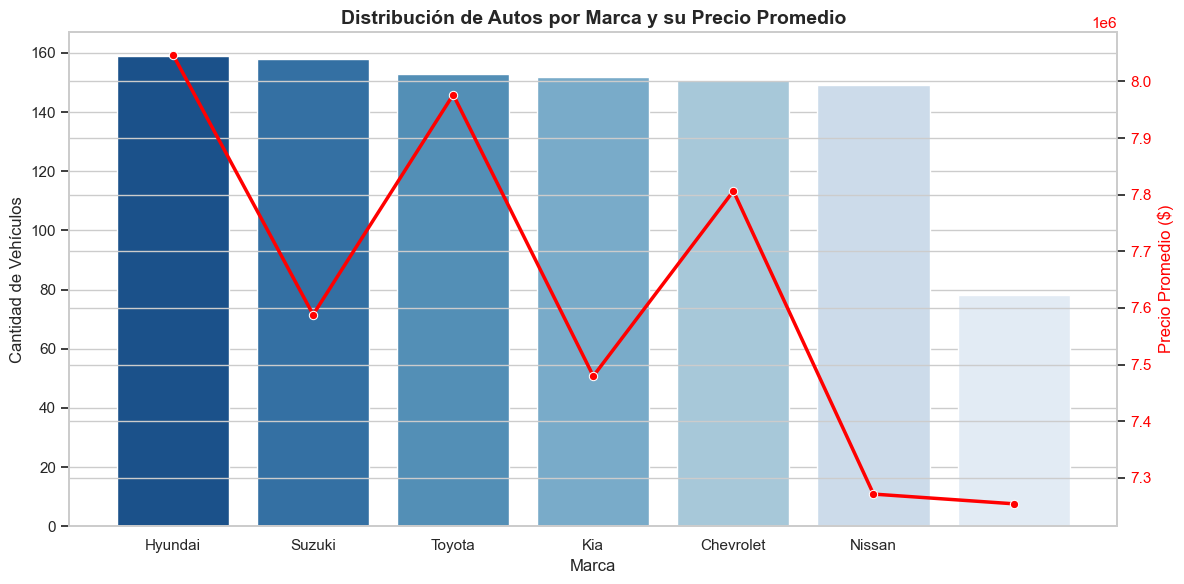

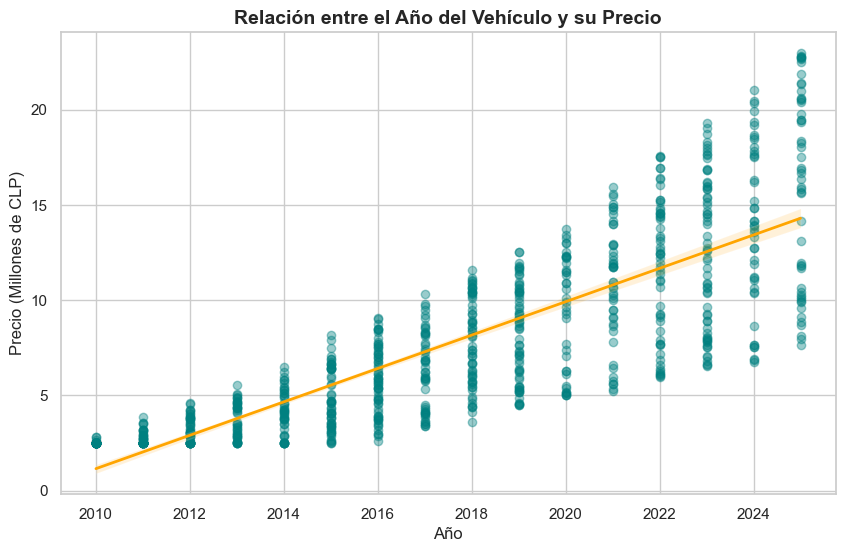

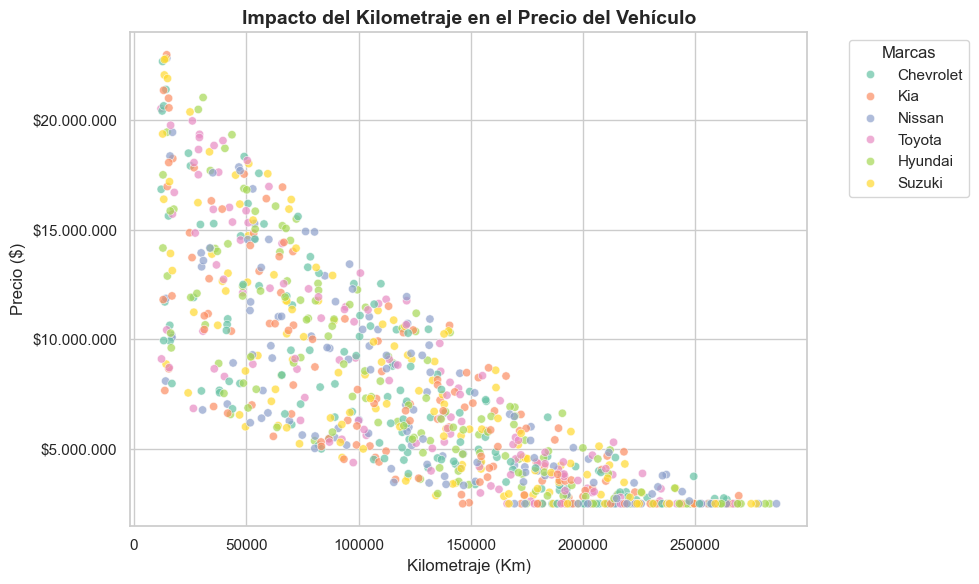

In [ ]:
#Creacion de Graficos

df_clean = df.copy()

#Normalización de texto
# Limpiamos el fuego tanto en el título completo como en la futura columna marca
df_clean['titulo'] = df_clean['titulo'].str.replace('🔥', '', regex=False).str.strip()

#Reemplazar "No disponible" por el valor nulo NaN
df_clean = df_clean.replace("No disponible", np.nan)

#Limpieza de la columna precio
df_clean['precio'] = df_clean['precio'].str.replace('$', '', regex=False)
df_clean['precio'] = df_clean['precio'].str.replace('.', '', regex=False)
df_clean['precio'] = df_clean['precio'].str.strip()
df_clean['precio'] = pd.to_numeric(df_clean['precio'], errors='coerce')

#Limpieza de la columna kilometraje
df_clean['kilometraje'] = df_clean['kilometraje'].str.lower().str.replace('km', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.lower().str.replace('s', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.replace('.', '', regex=False)
df_clean['kilometraje'] = df_clean['kilometraje'].str.strip()
df_clean['kilometraje'] = pd.to_numeric(df_clean['kilometraje'], errors='coerce')

#Limpieza de la columna año
df_clean['ano'] = pd.to_numeric(df_clean['ano'], errors='coerce')

#Extraer marca del título limpio
df_clean['marca'] = df_clean['titulo'].str.strip().str.capitalize().str.split().str[0]

df_clean.info()
df_clean.head()

#Ordenar por cantidad de mayor a menor
resumen_marcas = resumen_marcas.sort_values(by='cantidad', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=resumen_marcas, x='marca', y='cantidad', ax=ax1, palette='Blues_r', hue='marca', legend=False)

ax1.set_title('Distribución de Autos por Marca y su Precio Promedio', fontsize=14, fontweight='bold')
ax1.set_xlabel('Marca', fontsize=12)
ax1.set_ylabel('Cantidad de Vehículos', fontsize=12)

#Segundo eje para mostrar el precio promedio como una línea
ax2 = ax1.twinx()
sns.lineplot(data=resumen_marcas, x='marca', y='precio_promedio', ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Precio Promedio ($)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

#Grafico Tendencia de Depreciacion
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean, 
    x='ano', 
    y=df_clean['precio'] / 1_000_000,  # <-- Cambiado aquí
    scatter_kws={'alpha':0.4, 'color':'teal'}, 
    line_kws={'color':'orange', 'linewidth':2}
)

plt.title('Relación entre el Año del Vehículo y su Precio', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (Millones de CLP)', fontsize=12)  # <-- Cambiado aquí
plt.show()

#Grafico relación entre Kilometraje y Precio

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df_clean, x='kilometraje', y='precio', hue='marca', alpha=0.7, palette='Set2')

formatter = ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}".replace(",", "."))
ax.yaxis.set_major_formatter(formatter)
# ----------------------------------------

plt.title('Impacto del Kilometraje en el Precio del Vehículo', fontsize=14, fontweight='bold')
plt.xlabel('Kilometraje (Km)', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Marcas')
plt.tight_layout()
plt.show()

In [ ]:
#Definir la ruta de salida de forma segura
ruta_salida = os.path.join(ruta_base, "data", "processed", "autos_limpios.csv")

#Dropear filas que tengan valores nulos en el precio
df_final = df_clean.dropna(subset=['precio', 'ano', 'kilometraje'])

#Guardar a CSV
df_final.to_csv(ruta_salida, index=False, encoding='utf-8')

print(f"Datos listos para Machine Learning guardados en: {ruta_salida}")
print(f"Registros útiles restantes: {len(df_final)}")

Datos listos para Machine Learning guardados en: C:\users\sebas\desktop\proyecto-data-science\data\processed\autos_limpios.csv
Registros útiles restantes: 811
